# 01 — Análise Exploratória de Dados

**Dimensão 3 da rúbrica — 20 pontos.**

Toda visualização precisa de um parágrafo de interpretação logo abaixo.
Gráfico sem leitura perde metade dos pontos do critério.

# Dicionário dos dados:
https://www.kaggle.com/datasets/rikdifos/credit-card-approval-prediction/data


---


## -> application_record.csv

**Feature name	-  Explanation	-    Remarks**

**ID** -	Client number

**CODE_GENDER** -	Gender

**FLAG_OWN_CAR** -	Is there a car

**FLAG_OWN_REALTY** -	Is there a property

**CNT_CHILDREN** -	Number of children

**AMT_INCOME_TOTAL** -	Annual income

**NAME_INCOME_TYPE** -	Income category

**NAME_EDUCATION_TYPE** -	Education level

**NAME_FAMILY_STATUS** -	Marital status

**NAME_HOUSING_TYPE** -	Way of living

**DAYS_BIRTH** -	Birthday -	Count backwards from current day (0), -1 means yesterday

**DAYS_EMPLOYED** -	Start date of employment -	Count backwards from current day(0). If positive, it means the person currently unemployed.

**FLAG_MOBIL** -	Is there a mobile phone

**FLAG_WORK_PHONE** -	Is there a work phone

**FLAG_PHONE** -	Is there a phone

**FLAG_EMAIL** -	Is there an email

**OCCUPATION_TYPE** -	Occupation

**CNT_FAM_MEMBERS** -	Family size



---


## -> credit_record.csv
**Feature name	- Explanation -	Remarks**

**ID** -	Client number

**MONTHS_BALANCE** -	Record month -	The month of the extracted data is the starting point, backwards, 0 is the current month, -1 is the previous month, and so on

**STATUS**-	Status -	0: 1-29 days past due 1: 30-59 days past due 2: 60-89 days overdue 3: 90-119 days overdue 4: 120-149 days overdue 5: Overdue or bad debts, write-offs for more than 150 days C: paid off that month X: No loan for the month

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import zipfile

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

RAW_ZIP = Path("..") / "data" / "raw" / "BaseDadosFase2.zip"
PROCESSED = Path("..") / "data" / "processed"
TARGET = "target"                                            # PREENCHER: variável alvo

pd.set_option("display.max_columns", None)

In [3]:
#Leitura arquivos zip
from pathlib import Path
RAW_ZIP = Path("/content/BaseDadosFase2.zip")
with zipfile.ZipFile(RAW_ZIP, 'r') as z:
  df_perfil = pd.read_csv(z.open('application_record.csv'))
  df_credito = pd.read_csv(z.open('credit_record.csv'))

In [5]:
#Visualização primeiras linhas arquivo perfil
df_perfil.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [6]:
#Visualização primeiras linhas arquivo credito
df_credito.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


## 1. Visão geral

_Dimensões, tipos e primeira impressão do dataset._

In [7]:
df_perfil.info()
df_perfil.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

,count,mean,std,min,25%,50%,75%,max
ID,438557.0,6.022176e+06,571637.023257,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
CNT_CHILDREN,438557.0,4.273903e-01,0.724882,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,1.875243e+05,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
DAYS_BIRTH,438557.0,-1.599790e+04,4185.030007,-25201.0,-19483.0,-15630.0,-12514.0,-7489.0
DAYS_EMPLOYED,438557.0,6.056368e+04,138767.799647,-17531.0,-3103.0,-1467.0,-371.0,365243.0
FLAG_MOBIL,438557.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,438557.0,2.061328e-01,0.404527,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,438557.0,2.877710e-01,0.452724,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,438557.0,1.082071e-01,0.310642,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,438557.0,2.194465e+00,0.897207,1.0,2.0,2.0,3.0,20.0


Observações arquivo Perfil:
- transformar DAYS_BIRTH e DAYS_EMPLOYED em anos para facilitar a visualização/compreenção dos dados.
- ID não tem relevância de cálculos/métricas.
- Possível transformar CODE_GENDER, FLAG_OWN_CAR e FLAG_OWN_REALTY em variáveis numéricas 1 / 0 para poder trabalhar com elas.

In [8]:
df_credito.info()
df_credito.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


,count,mean,std,min,25%,50%,75%,max
ID,1048575.0,5.068286e+06,46150.578505,5001711.0,5023644.0,5062104.0,5113856.0,5150487.0
MONTHS_BALANCE,1048575.0,-1.913700e+01,14.023498,-60.0,-29.0,-17.0,-7.0,0.0


Observações arquivo Crédito:
- Possível transformar STATUS em variáveis numéricas para poder trabalhar com ela.

## 2. Distribuição das variáveis

**Interpretação:** _preencher._

Text(0.5, 0, 'Estado Civil')

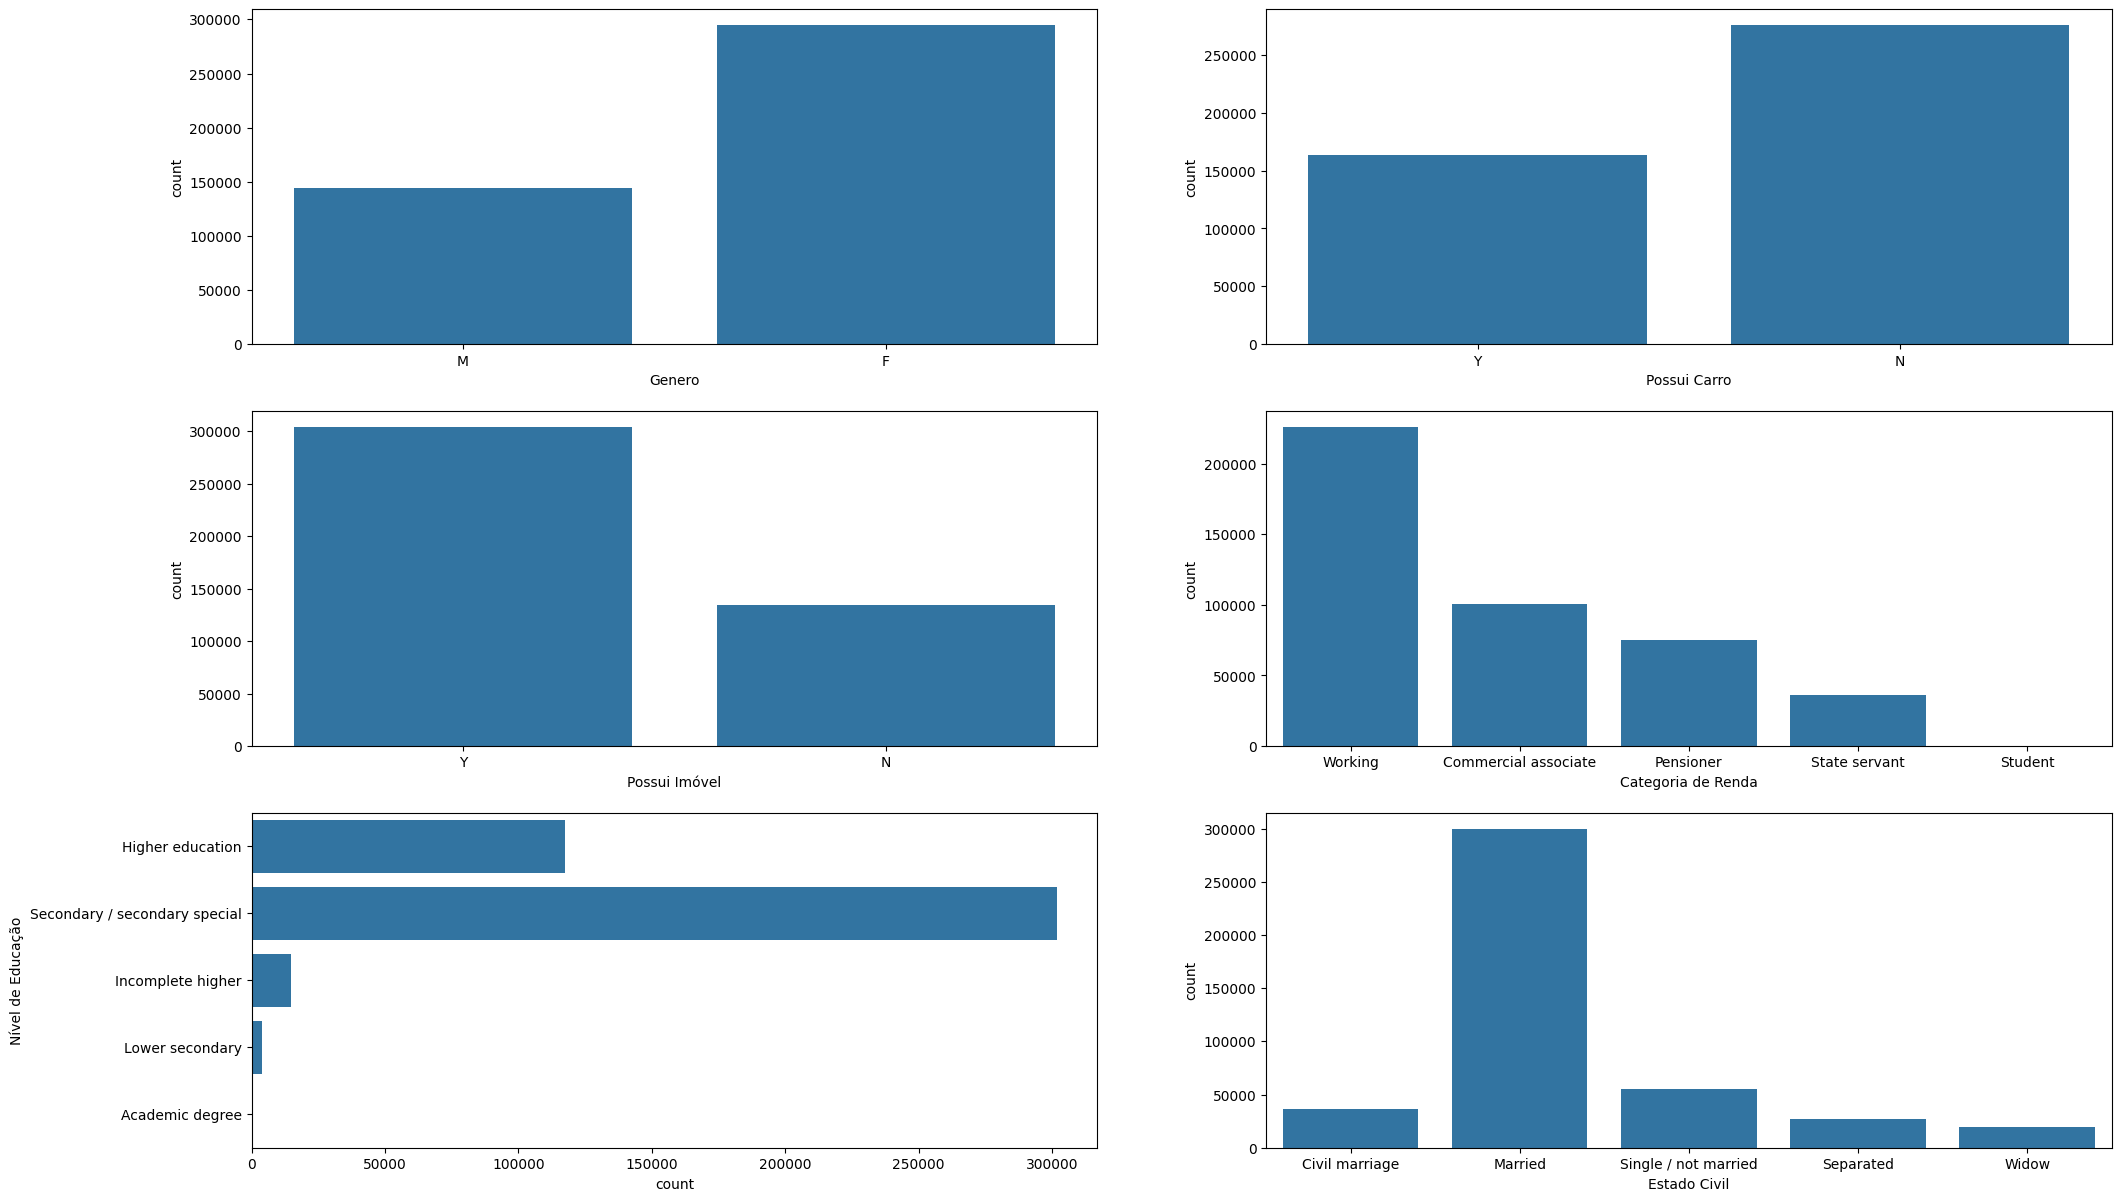

In [31]:
# histogramas / boxplots
plt.figure(figsize=(24,20))

plt.subplot(4,2,1)
fig = sns.countplot(data=df_perfil, x='CODE_GENDER')
fig.set_title("")
fig.set_xlabel("Genero")

plt.subplot(4,2,2)
fig = sns.countplot(data=df_perfil, x='FLAG_OWN_CAR')
fig.set_title("")
fig.set_xlabel("Possui Carro")

plt.subplot(4,2,3)
fig = sns.countplot(data=df_perfil, x='FLAG_OWN_REALTY')
fig.set_title("")
fig.set_xlabel("Possui Imóvel")

plt.subplot(4,2,4)
fig = sns.countplot(data=df_perfil, x='NAME_INCOME_TYPE')
fig.set_title("")
fig.set_xlabel("Categoria de Renda")

plt.subplot(4,2,5)
fig = sns.countplot(data=df_perfil, y='NAME_EDUCATION_TYPE')
fig.set_title("")
fig.set_ylabel("Nível de Educação")

plt.subplot(4,2,6)
fig = sns.countplot(data=df_perfil, x='NAME_FAMILY_STATUS')
fig.set_title("")
fig.set_xlabel("Estado Civil")

Text(0, 0.5, 'Ocupação')

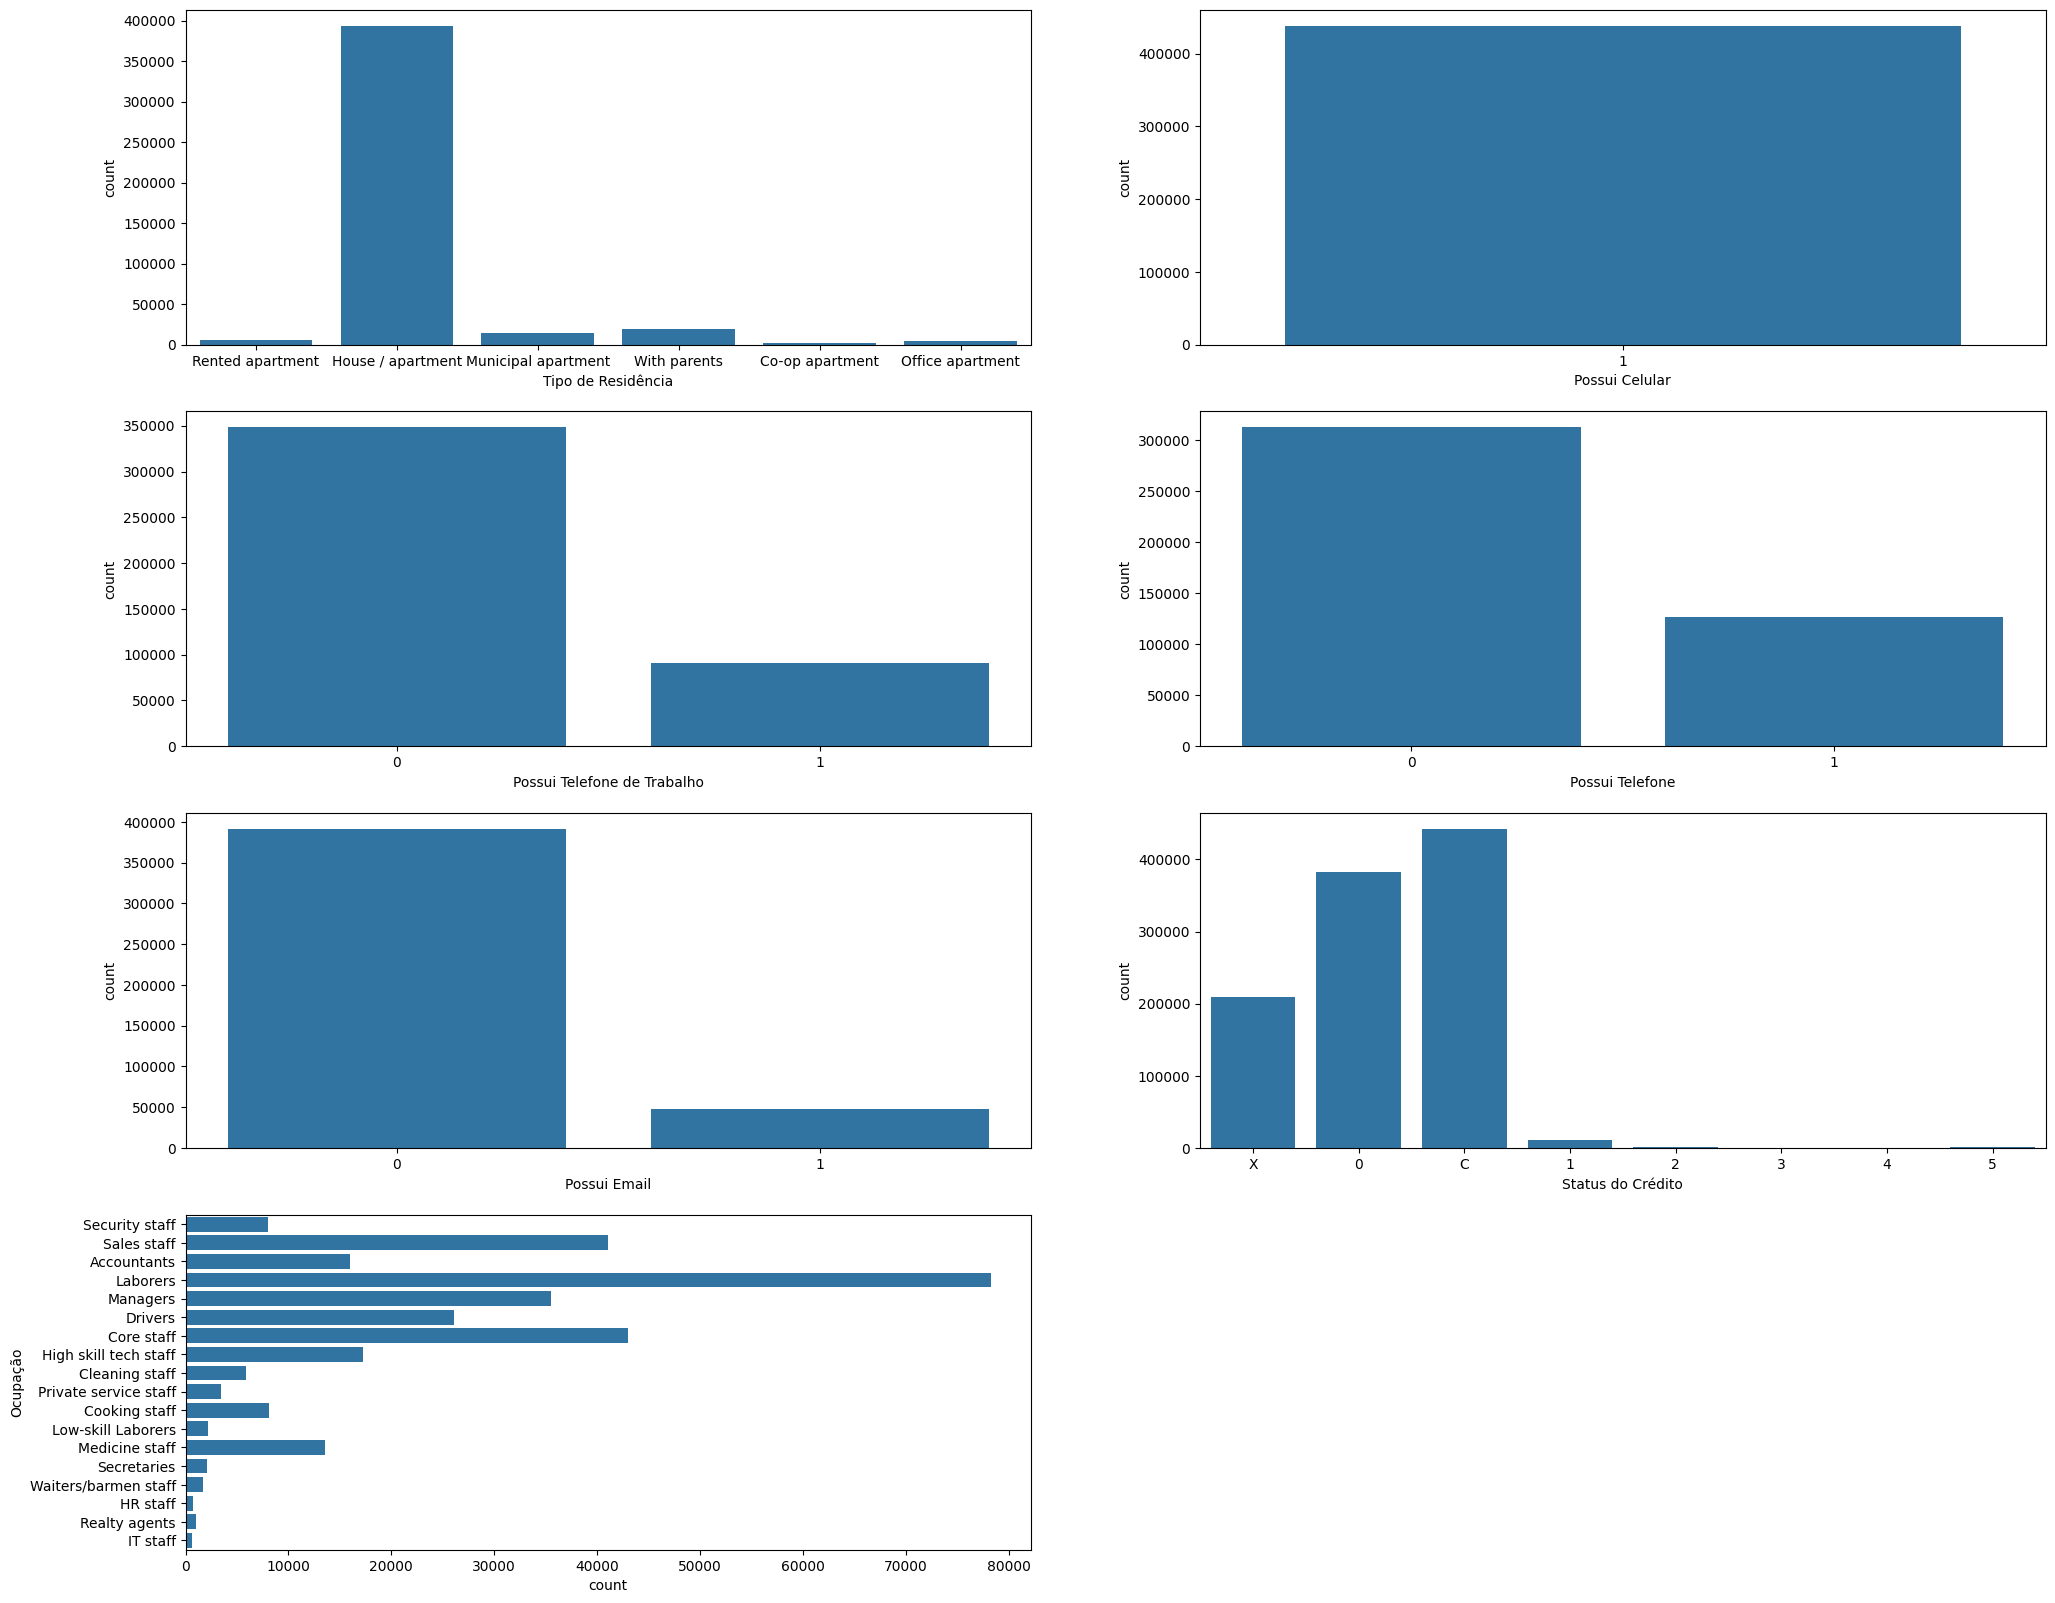

In [33]:
plt.figure(figsize=(24,20))

plt.subplot(4,2,1)
fig = sns.countplot(data=df_perfil, x='NAME_HOUSING_TYPE')
fig.set_title("")
fig.set_xlabel("Tipo de Residência")

plt.subplot(4,2,2)
fig = sns.countplot(data=df_perfil, x='FLAG_MOBIL')
fig.set_title("")
fig.set_xlabel("Possui Celular")

plt.subplot(4,2,3)
fig = sns.countplot(data=df_perfil, x='FLAG_WORK_PHONE')
fig.set_title("")
fig.set_xlabel("Possui Telefone de Trabalho")

plt.subplot(4,2,4)
fig = sns.countplot(data=df_perfil, x='FLAG_PHONE')
fig.set_title("")
fig.set_xlabel("Possui Telefone")

plt.subplot(4,2,5)
fig = sns.countplot(data=df_perfil, x='FLAG_EMAIL')
fig.set_title("")
fig.set_xlabel("Possui Email")

plt.subplot(4,2,6)
fig = sns.countplot(data=df_credito, x='STATUS')
fig.set_title("")
fig.set_xlabel("Status do Crédito")

plt.subplot(4,2,7)
fig = sns.countplot(data=df_perfil, y='OCCUPATION_TYPE')
fig.set_title("")
fig.set_ylabel("Ocupação")

In [34]:
df_perfil['FLAG_MOBIL'].value_counts()

,count
FLAG_MOBIL,
1,438557


Foi verificado que 100% dos indivíduos possuem celular, tornando essa uma variável irrelevante no contexto.

In [41]:
#Transformando a variável DAYS_BIRTH em anos
df_perfil['IDADE'] = (df_perfil['DAYS_BIRTH'].abs() / 365.25).astype(int)
display(df_perfil[['DAYS_BIRTH', 'IDADE']].head())

,DAYS_BIRTH,IDADE
0,-12005,32
1,-12005,32
2,-21474,58
3,-19110,52
4,-19110,52


In [46]:
#Transformando a variável DAYS_EMPLOYED em anos e eliminando o outlier - adicionado após a consulta dos outliers no item 4
df_perfil['ANOS_EMPREGADO'] = df_perfil['DAYS_EMPLOYED'].apply(
    lambda x: abs(x) / 365.25 if x < 0 else 0)

display(df_perfil[['DAYS_EMPLOYED', 'ANOS_EMPREGADO']].head())

,DAYS_EMPLOYED,ANOS_EMPREGADO
0,-4542,12.435318
1,-4542,12.435318
2,-1134,3.104723
3,-3051,8.353183
4,-3051,8.353183


Text(0.5, 0, 'Tempo de atraso em meses')

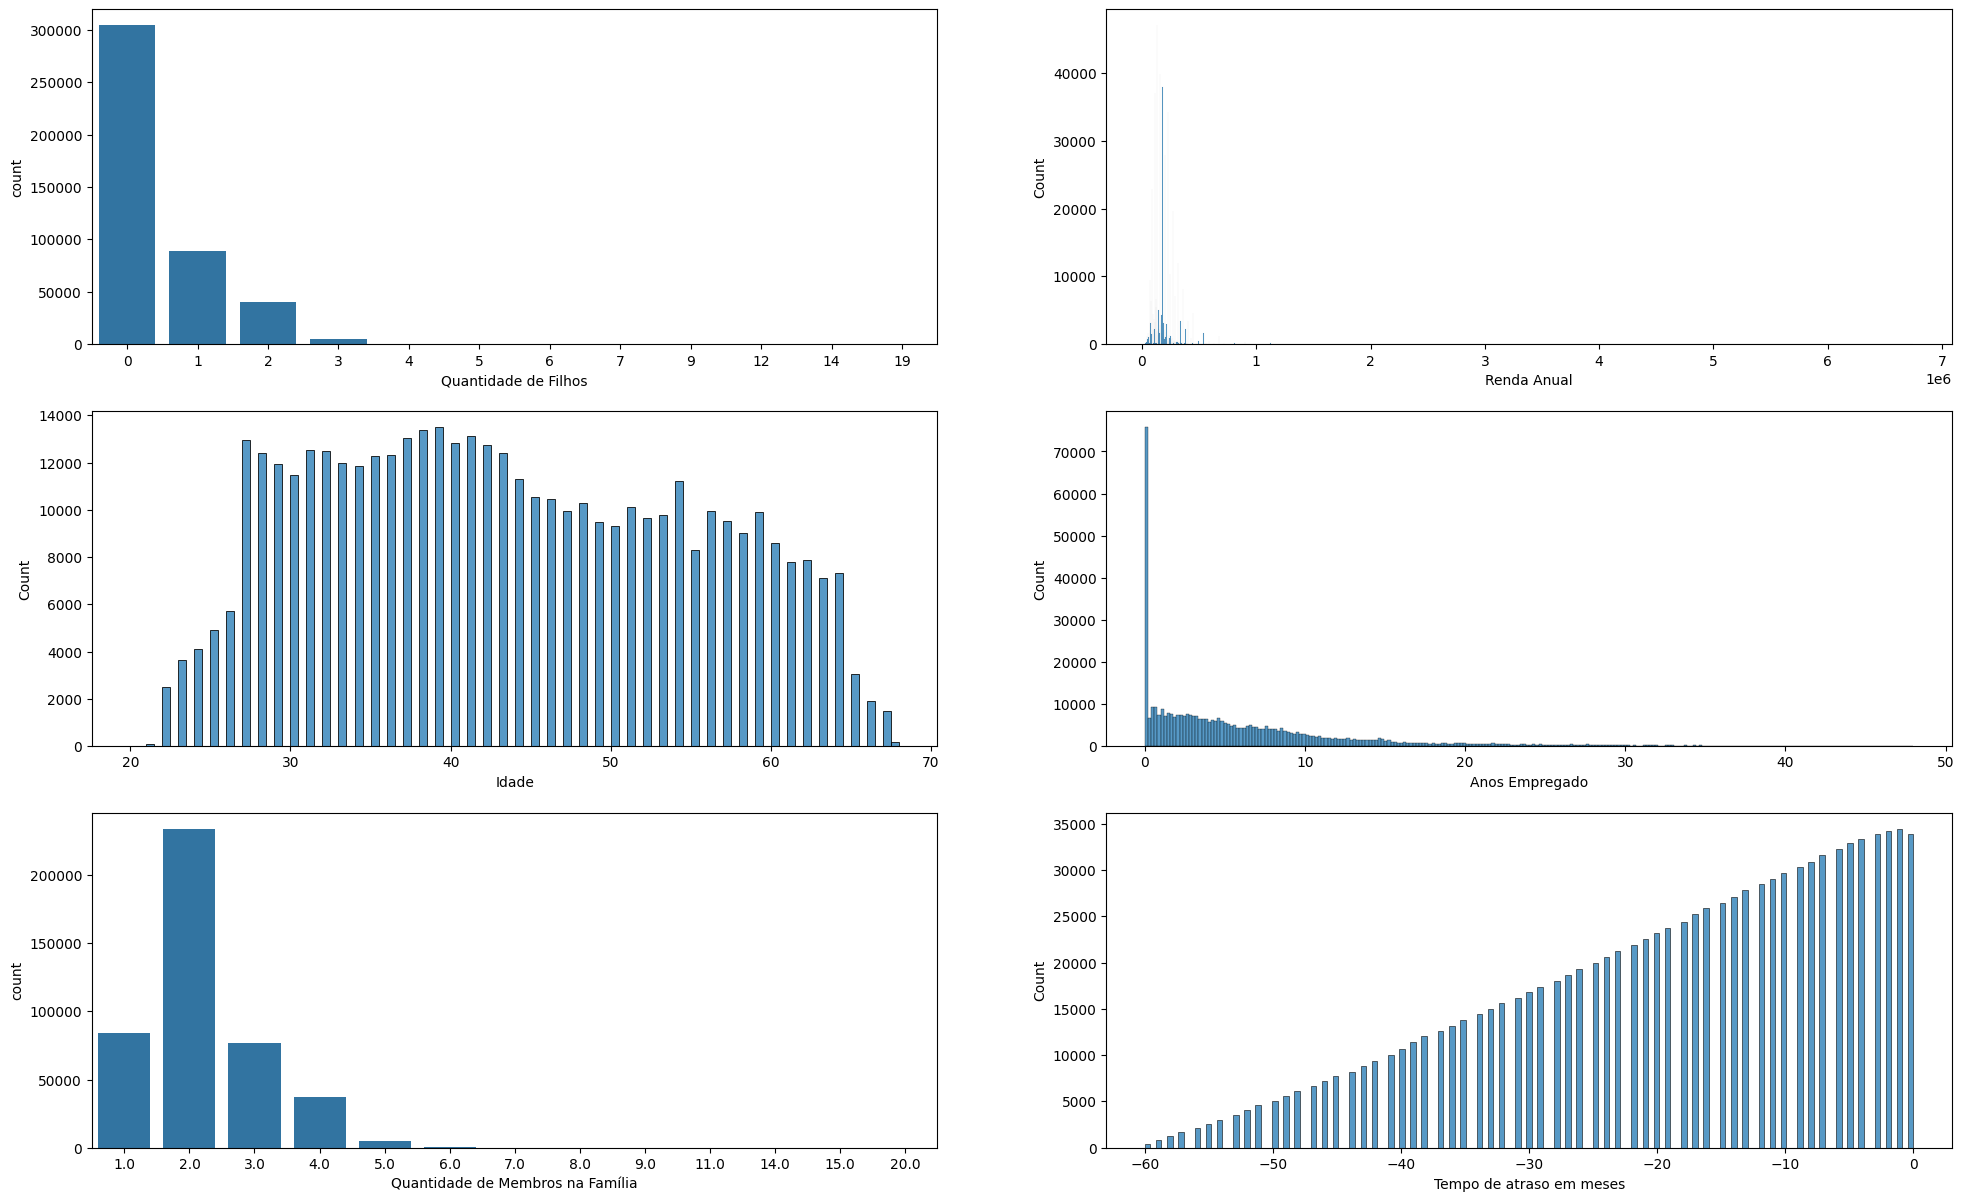

In [47]:
plt.figure(figsize=(24,20))

plt.subplot(4,2,1)
fig = sns.countplot(data=df_perfil, x='CNT_CHILDREN')
fig.set_title("")
fig.set_xlabel("Quantidade de Filhos")

plt.subplot(4,2,2)
fig = sns.histplot(data=df_perfil, x="AMT_INCOME_TOTAL")
fig.set_title("")
fig.set_xlabel("Renda Anual")

plt.subplot(4,2,3)
fig = sns.histplot(data=df_perfil, x="IDADE")
fig.set_title("")
fig.set_xlabel("Idade")

plt.subplot(4,2,4)
fig = sns.histplot(data=df_perfil, x="ANOS_EMPREGADO")
fig.set_title("")
fig.set_xlabel("Anos Empregado")

plt.subplot(4,2,5)
fig = sns.countplot(data=df_perfil, x="CNT_FAM_MEMBERS")
fig.set_title("")
fig.set_xlabel("Quantidade de Membros na Família")

plt.subplot(4,2,6)
fig = sns.histplot(data=df_credito, x="MONTHS_BALANCE")
fig.set_title("")
fig.set_xlabel("Tempo de atraso em meses")

## 3. Correlações

**Interpretação:** _comente cada correlação relevante, uma a uma._

In [55]:
#Transformação das variáveis em numericas para que possam entrar no mapa de correlação
df_perfil['CODE_GENDER'] = df_perfil['CODE_GENDER'].map({'M': 1, 'F': 0})
df_perfil['FLAG_OWN_CAR'] = df_perfil['FLAG_OWN_CAR'].map({'Y': 1, 'N': 0})
df_perfil['FLAG_OWN_REALTY'] = df_perfil['FLAG_OWN_REALTY'].map({'Y': 1, 'N': 0})

In [56]:
# Mapeando a escolaridade
ordem_educacao = {
    'Lower secondary': 0,
    'Secondary / secondary special': 1,
    'Incomplete higher': 2,
    'Higher education': 3,
    'Academic degree': 4
}

df_perfil['NAME_EDUCATION_TYPE_NUM'] = df_perfil['NAME_EDUCATION_TYPE'].map(ordem_educacao)

<Axes: >

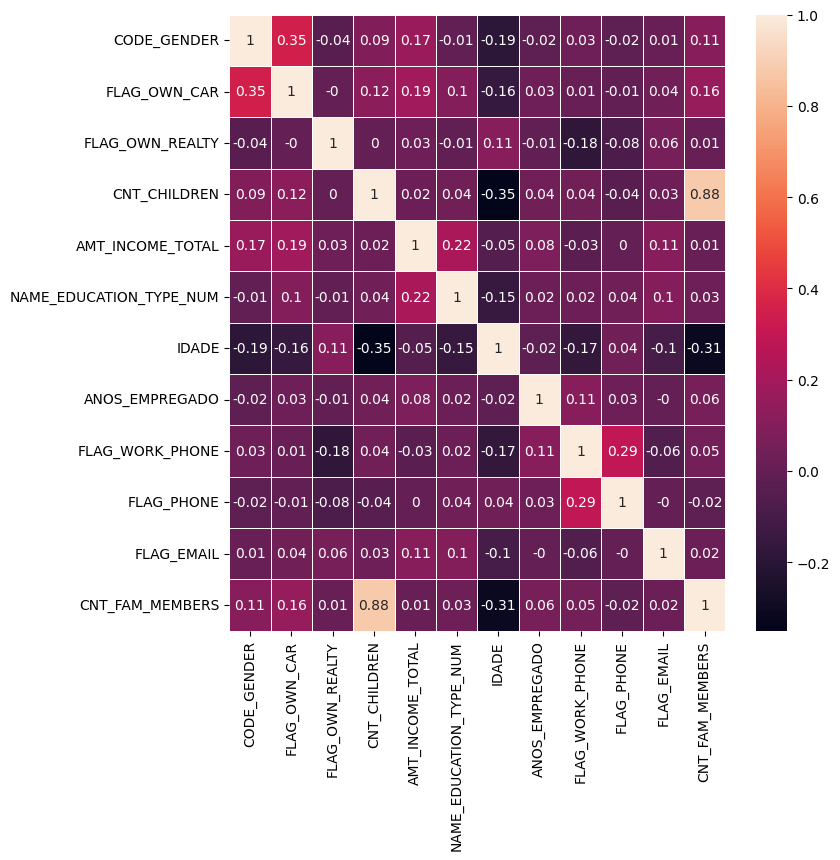

In [58]:
# heatmap de correlação
correlation_matrix = df_perfil[['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_EDUCATION_TYPE_NUM',
                               'IDADE', 'ANOS_EMPREGADO', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS'
                                ]].corr().round(2)

fig, ax = plt.subplots(figsize=(8,8))
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax)

## 4. Outliers

**Interpretação:** _remover, winsorizar ou manter? Justifique._

Text(0, 0.5, 'Tempo de atraso em meses')

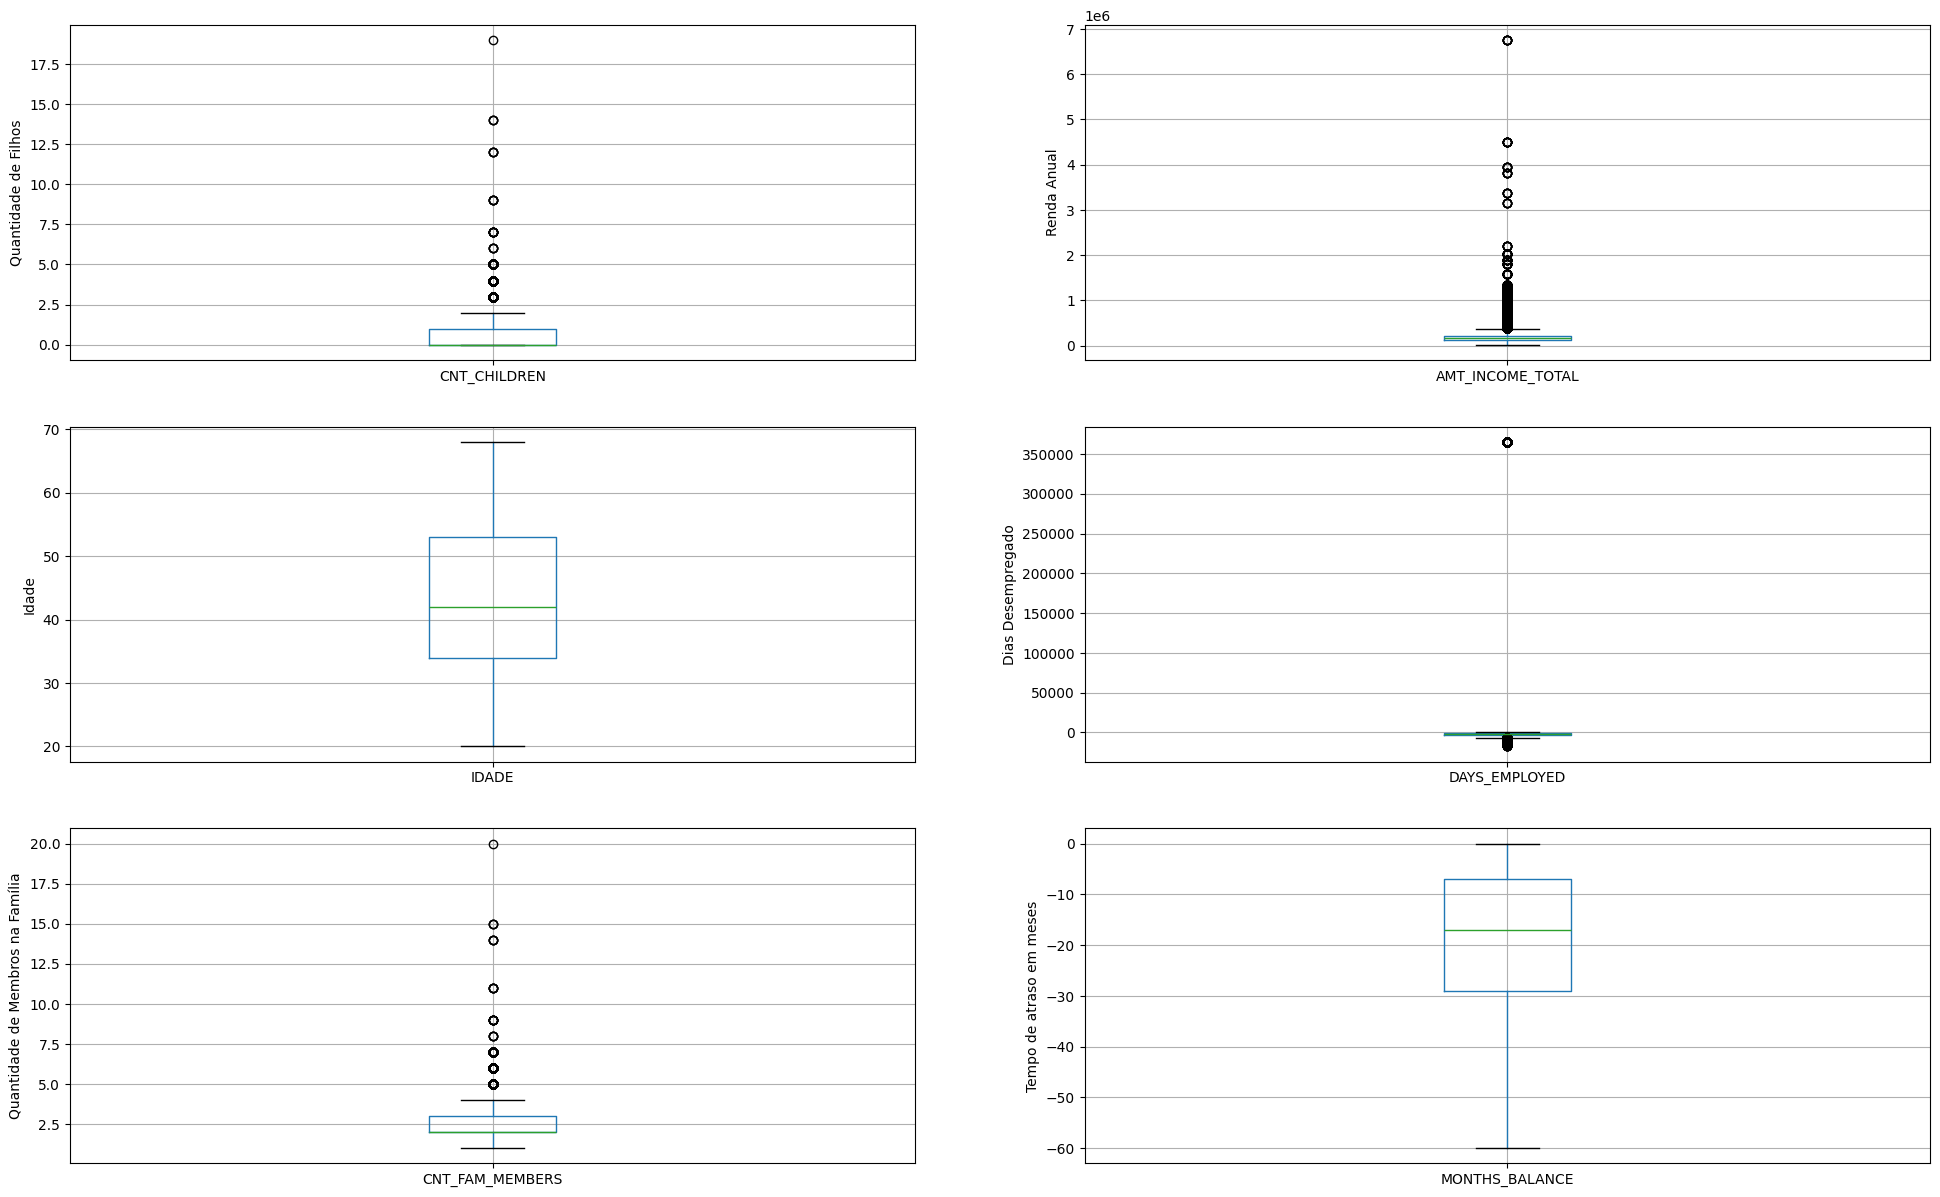

In [45]:
# detecção de outliers
plt.figure(figsize=(24,20))

plt.subplot(4,2,1)
fig = df_perfil.boxplot(column = "CNT_CHILDREN")
fig.set_title("")
fig.set_ylabel("Quantidade de Filhos")

plt.subplot(4,2,2)
fig = df_perfil.boxplot(column = "AMT_INCOME_TOTAL")
fig.set_title("")
fig.set_ylabel("Renda Anual")

plt.subplot(4,2,3)
fig = df_perfil.boxplot(column = "IDADE")
fig.set_title("")
fig.set_ylabel("Idade")

plt.subplot(4,2,4)
fig = df_perfil.boxplot(column = "DAYS_EMPLOYED")
fig.set_title("")
fig.set_ylabel("Dias Desempregado")

plt.subplot(4,2,5)
fig = df_perfil.boxplot(column = "CNT_FAM_MEMBERS")
fig.set_title("")
fig.set_ylabel("Quantidade de Membros na Família")

plt.subplot(4,2,6)
fig = df_credito.boxplot(column = "MONTHS_BALANCE")
fig.set_title("")
fig.set_ylabel("Tempo de atraso em meses")

In [42]:
df_perfil['DAYS_EMPLOYED'].value_counts()

,count
DAYS_EMPLOYED,
365243,75329
-218,262
-1678,251
-249,241
-978,240
...,...
-7118,1
-6623,1
-10472,1


Os outliers serão mantidos entendedo que são relevantes por se tratarem da realidade do negócio, com excessão da variável DAYS_EMPLOYED que, só apresenta um valor positivo discrepante, enquadrando-se assim como desempregados, portanto será substituído por zero.

<Axes: >

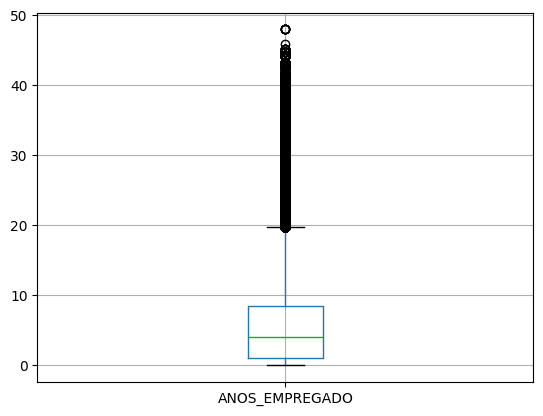

In [51]:
#Boxplot pós ajuste do maior outlier da variável DAYS_EMPLOYED
df_perfil.boxplot(column = "ANOS_EMPREGADO")

## 5. Balanceamento de classes

**Interpretação:** _qual a proporção entre as classes e o que isso implica na escolha das métricas?_

In [ ]:
df[TARGET].value_counts(normalize=True)

## 6. Síntese da EDA

_Amarre os achados em uma narrativa única — é ela que vira o storytelling da apresentação._